In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

# Load dataset
df = pd.read_csv(r"D:\capstone project dataset\11.01 final\CRA_DATASET.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (20286, 32)


,State,District,Year,Season,Yield_kg_per_ha,Yield_Z_Score,Soil_Organic_Carbon,Soil_pH,N,P,...,PM10,Aerosol_Optical_Depth,CO2_Concentration,Irrigation_Coverage,Groundwater_Depth,Irrigation_Source,Nutrient_Intensity,Seed_Variety,Temp_Anomaly,Yield_log
0,Chhattisgarh,Durg,2000,Kharif,624.89,-1.464474,0.5584,7.24,15.62225,7.49868,...,315.807818,2.515496,445.512719,28.420999,34.783504,Canal,36.868461,Local,2.306358,6.439175
1,Chhattisgarh,Durg,2000,Kharif,792.52,-0.970182,0.5246,6.84,21.39804,9.51024,...,405.569398,2.653901,440.650942,25.993150,26.626331,Canal,44.369859,Local,-0.693642,6.676479
2,Chhattisgarh,Durg,2000,Kharif,506.84,-0.404961,0.5162,6.67,9.12312,5.06840,...,212.475942,1.377346,429.083769,32.800820,28.163458,Canal,23.314403,Local,-2.693642,6.230166
3,Chhattisgarh,Durg,2001,Kharif,1294.13,-0.775472,0.5445,6.83,32.35325,15.52956,...,154.214247,3.000000,436.390189,35.118709,26.606628,Canal,76.353569,Local,2.306358,7.166366
4,Chhattisgarh,Durg,2001,Kharif,672.21,-1.053551,0.5506,7.75,18.14967,8.06652,...,62.953206,1.497527,414.469057,26.231926,30.003135,Canal,37.634110,Hybrid,-0.693642,6.512057


In [2]:
# Target
target = "Yield_kg_per_ha"

# Drop target and non-predictive identifiers
X = df.drop(columns=[target])
y = df[target]

# Identify categorical and numerical features
categorical_features = [
    "State", "District", "Season",
    "Irrigation_Source", "Seed_Variety"
]

numerical_features = [col for col in X.columns if col not in categorical_features]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))


Numerical features: 26
Categorical features: 5


In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 16228
Testing samples: 4058


In [4]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)


In [5]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)


In [6]:
model.fit(X_train, y_train)
print("Model training completed ✅")


Model training completed ✅


In [7]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")


Model Performance:
RMSE: 2.85
MAE : 0.37
R²  : 1.000


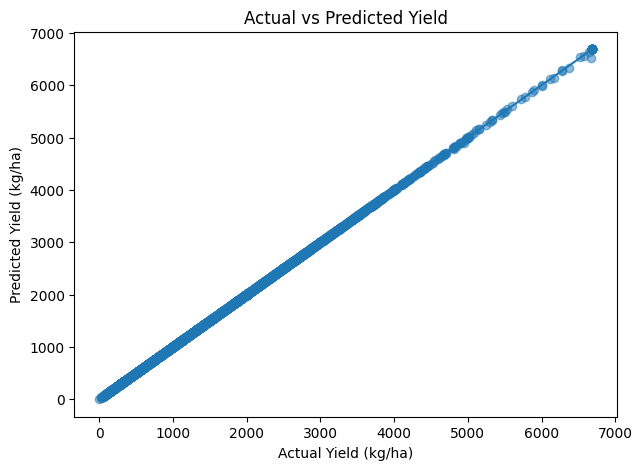

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.title("Actual vs Predicted Yield")
plt.show()


In [9]:
print("""
This model learns:
- Climate stress effects (heatwaves, drought, anomalies)
- Soil buffering capacity (SOC, WHC, pH)
- Irrigation-based resilience
- Seasonal and regional adaptation

This satisfies the 'Climate-Aware Yield Prediction' objective.
""")



This model learns:
- Climate stress effects (heatwaves, drought, anomalies)
- Soil buffering capacity (SOC, WHC, pH)
- Irrigation-based resilience
- Seasonal and regional adaptation

This satisfies the 'Climate-Aware Yield Prediction' objective.



In [10]:
df.columns.tolist()


['State',
 'District',
 'Year',
 'Season',
 'Yield_kg_per_ha',
 'Yield_Z_Score',
 'Soil_Organic_Carbon',
 'Soil_pH',
 'N',
 'P',
 'K',
 'Water_Holding_Capacity',
 'Electrical_Conductivity',
 'Avg_Temperature',
 'Heatwave_Days',
 'Dry_Spell_Count',
 'Rainfall_mm',
 'Relative_Humidity',
 'Wind_Speed',
 'Solar_Radiation',
 'Ground_Level_Ozone',
 'PM2_5',
 'PM10',
 'Aerosol_Optical_Depth',
 'CO2_Concentration',
 'Irrigation_Coverage',
 'Groundwater_Depth',
 'Irrigation_Source',
 'Nutrient_Intensity',
 'Seed_Variety',
 'Temp_Anomaly',
 'Yield_log']

In [11]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nBasic stats:")
df.describe()


Missing values per column:
State                      0
District                   0
Year                       0
Season                     0
Yield_kg_per_ha            0
Yield_Z_Score              0
Soil_Organic_Carbon        0
Soil_pH                    0
N                          0
P                          0
K                          0
Water_Holding_Capacity     0
Electrical_Conductivity    0
Avg_Temperature            0
Heatwave_Days              0
Dry_Spell_Count            0
Rainfall_mm                0
Relative_Humidity          0
Wind_Speed                 0
Solar_Radiation            0
Ground_Level_Ozone         0
PM2_5                      0
PM10                       0
Aerosol_Optical_Depth      0
CO2_Concentration          0
Irrigation_Coverage        0
Groundwater_Depth          0
Irrigation_Source          0
Nutrient_Intensity         0
Seed_Variety               0
Temp_Anomaly               0
Yield_log                  0
dtype: int64

Basic stats:


,Year,Yield_kg_per_ha,Yield_Z_Score,Soil_Organic_Carbon,Soil_pH,N,P,K,Water_Holding_Capacity,Electrical_Conductivity,...,Ground_Level_Ozone,PM2_5,PM10,Aerosol_Optical_Depth,CO2_Concentration,Irrigation_Coverage,Groundwater_Depth,Nutrient_Intensity,Temp_Anomaly,Yield_log
count,20286.000000,20286.000000,2.028600e+04,20286.000000,20286.000000,20286.000000,20286.000000,20286.000000,20286.000000,20286.000000,...,20286.000000,20286.000000,20286.000000,20286.000000,20286.000000,20286.000000,20286.000000,20286.000000,2.028600e+04,20286.000000
mean,2006.208715,1625.336410,1.479117e-13,0.529251,6.879488,43.366630,20.757728,31.054425,39.425512,1.128852,...,53.929554,141.949653,243.604910,1.851628,416.484042,27.102181,33.024574,80.837580,8.271714e-11,7.095500
std,9.306382,1156.555100,9.999014e-01,0.074204,0.594893,34.464189,16.197140,23.030986,6.621797,0.161169,...,35.242212,84.743353,141.244379,0.838799,18.192232,7.693469,4.305656,68.649729,2.612386e+00,0.871794
min,1966.000000,0.280000,-2.047198e+00,0.412100,5.500000,0.007560,0.003360,0.007560,30.001096,0.950400,...,5.000000,5.000000,10.000000,0.050948,380.000000,5.000000,16.989258,0.018479,-5.399520e+00,0.246860
25%,2003.000000,746.142500,-5.489552e-01,0.461050,6.470000,15.283417,7.927400,14.367780,34.303457,1.030900,...,21.540626,68.115378,122.304174,1.150135,406.270390,21.912766,30.104149,37.572067,-2.084942e+00,6.616256
50%,2008.000000,1351.556072,-1.024348e-01,0.528500,6.880000,34.894380,16.363680,26.483505,38.639245,1.082100,...,52.603763,141.443735,241.947716,1.880943,418.151719,27.131770,33.021880,53.333333,0.000000e+00,7.209751
75%,2013.000000,2301.880000,3.769554e-01,0.571000,7.280000,70.320735,32.732460,40.000000,42.931262,1.179000,...,84.464311,215.960118,365.253927,2.622255,428.968762,32.292948,35.971110,111.839650,2.100480e+00,7.741916
max,2017.000000,6686.810000,5.679783e+01,0.774500,8.500000,1050.545520,583.636400,1050.545520,59.999523,1.810400,...,129.984660,300.000000,500.000000,3.000000,474.224432,58.411960,45.000000,2660.540706,5.721881e+00,10.974466


In [12]:
# Define target
target = "Yield_kg_per_ha"

# Remove leakage columns
leakage_cols = ["Yield_Z_Score", "Yield_log"]

df_clean = df.drop(columns=leakage_cols)

print("Removed leakage columns:", leakage_cols)
print("Remaining columns:", df_clean.columns.tolist())


Removed leakage columns: ['Yield_Z_Score', 'Yield_log']
Remaining columns: ['State', 'District', 'Year', 'Season', 'Yield_kg_per_ha', 'Soil_Organic_Carbon', 'Soil_pH', 'N', 'P', 'K', 'Water_Holding_Capacity', 'Electrical_Conductivity', 'Avg_Temperature', 'Heatwave_Days', 'Dry_Spell_Count', 'Rainfall_mm', 'Relative_Humidity', 'Wind_Speed', 'Solar_Radiation', 'Ground_Level_Ozone', 'PM2_5', 'PM10', 'Aerosol_Optical_Depth', 'CO2_Concentration', 'Irrigation_Coverage', 'Groundwater_Depth', 'Irrigation_Source', 'Nutrient_Intensity', 'Seed_Variety', 'Temp_Anomaly']


In [13]:
X = df_clean.drop(columns=[target])
y = df_clean[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20286, 29)
y shape: (20286,)


In [14]:
df.to_csv("CRA_DATASET_FULL_REFERENCE.csv", index=False)
print("Saved: CRA_DATASET_FULL_REFERENCE.csv")


Saved: CRA_DATASET_FULL_REFERENCE.csv


In [15]:
df_model_ready = df.drop(columns=["Yield_Z_Score", "Yield_log"])
df_model_ready.to_csv("CRA_DATASET_MODEL_READY.csv", index=False)

print("Saved: CRA_DATASET_MODEL_READY.csv")
print("Shape:", df_model_ready.shape)


Saved: CRA_DATASET_MODEL_READY.csv
Shape: (20286, 30)


In [16]:
from sklearn.model_selection import train_test_split

categorical_features = [
    "State",
    "District",
    "Season",
    "Irrigation_Source",
    "Seed_Variety"
]

numerical_features = [col for col in X.columns if col not in categorical_features]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))


Numerical features: 24
Categorical features: 5


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (16228, 29)
Test size : (4058, 29)


In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,        # keep reasonable
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)


In [20]:
model.fit(X_train, y_train)
print("Leakage-free climate-aware yield model trained ✅")


Leakage-free climate-aware yield model trained ✅


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance (Leakage-Free):")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")


Model Performance (Leakage-Free):
RMSE: 309.86
MAE : 98.57
R²  : 0.927


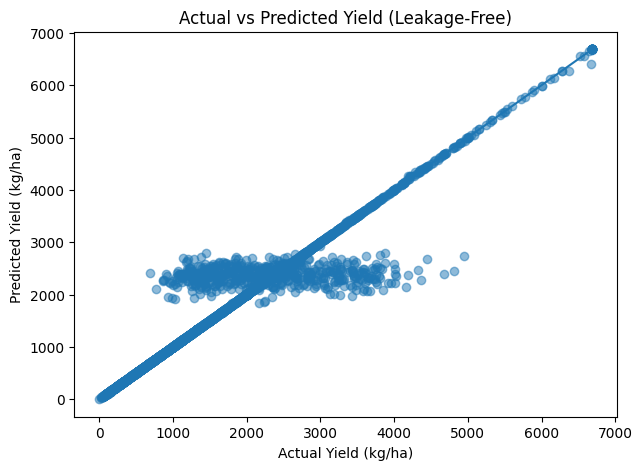

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.title("Actual vs Predicted Yield (Leakage-Free)")
plt.show()


In [23]:
import joblib

joblib.dump(model, "CRA_Yield_Prediction_Model.joblib")

print("Model saved as CRA_Yield_Prediction_Model.joblib")


Model saved as CRA_Yield_Prediction_Model.joblib
